# Since this is a regression project, we do not use:

Accuracy
Precision
Recall
F1-score
ROC-AUC
Confusion Matrix

Those are classification metrics.

Instead, we evaluate using:

R² Score
Mean Absolute Error (MAE)
Mean Squared Error (MSE)
Root Mean Squared Error (RMSE)

Evaluate the final regression models.

# Import Libraries

In [16]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Load Test Data

# cycle and period

In [17]:
X_test = joblib.load("../processed_data/Xc_test.pkl")
y_test = joblib.load("../processed_data/yc_test.pkl")

In [18]:
Xp_test = joblib.load("../processed_data/Xp_test.pkl")
yp_test = joblib.load("../processed_data/yp_test.pkl")

# Load Best Models

In [19]:
cycle_models = {
    "Linear Regression": joblib.load("../models/trained_models/Linear_Regression_cycle.pkl"),
    "Decision Tree": joblib.load("../models/trained_models/Decision_Tree_cycle.pkl"),
    "Random Forest": joblib.load("../models/trained_models/Random_Forest_cycle.pkl"),
    "KNN": joblib.load("../models/trained_models/KNN_cycle.pkl"),
    "SVR": joblib.load("../models/trained_models/SVR_cycle.pkl"),
    "Gradient Boosting": joblib.load("../models/trained_models/Gradient_Boosting_cycle.pkl"),
    "XGBoost": joblib.load("../models/trained_models/XGBoost_cycle.pkl")
}


In [20]:
period_models = {
    "Linear Regression": joblib.load("../models/trained_models/Linear_Regression_period.pkl"),
    "Decision Tree": joblib.load("../models/trained_models/Decision_Tree_period.pkl"),
    "Random Forest": joblib.load("../models/trained_models/Random_Forest_period.pkl"),
    "KNN": joblib.load("../models/trained_models/KNN_period.pkl"),
    "SVR": joblib.load("../models/trained_models/SVR_period.pkl"),
    "Gradient Boosting": joblib.load("../models/trained_models/Gradient_Boosting_period.pkl"),
    "XGBoost": joblib.load("../models/trained_models/XGBoost_period.pkl")
}


# Evaluation Function

In [21]:
def evaluate_models(models, X_test, y_test):

    results = []

    for name, model in models.items():

        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Model": name,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2 Score": r2
        })

    return pd.DataFrame(results).sort_values(
        by="R2 Score",
        ascending=False
    )

# Cycle Evaluation

In [22]:
cycle_results = evaluate_models(
    cycle_models,
    X_test,
    y_test
)

display(cycle_results)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.749292,7.787506,2.790610,0.591635
5,Gradient Boosting,1.756961,7.835379,2.799175,0.589125
2,Random Forest,1.927312,8.561534,2.926010,0.551047
6,XGBoost,1.932137,8.804719,2.967275,0.538294
4,SVR,1.821014,9.390947,3.064465,0.507554
3,KNN,2.261474,11.261839,3.355866,0.409447
1,Decision Tree,2.672632,17.954737,4.237303,0.058482


# Period Evaluation

In [23]:
period_results = evaluate_models(
    period_models,
    Xp_test,
    yp_test
)

display(period_results)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.481947,2.858467,1.690700,-0.004237
5,Gradient Boosting,1.482705,2.863431,1.692167,-0.005981
6,XGBoost,1.482691,2.863451,1.692173,-0.005988
1,Decision Tree,1.482691,2.863452,1.692174,-0.005988
2,Random Forest,1.482873,2.864355,1.692440,-0.006305
4,SVR,1.491416,2.998686,1.731672,-0.053499
3,KNN,1.561544,3.410975,1.846883,-0.198344


# Save Results

In [24]:
cycle_results.to_csv(
    "../results/cycle_model_results.csv",
    index=False
)

period_results.to_csv(
    "../results/period_model_results.csv",
    index=False
)

# Visualizations

# Model Comparison

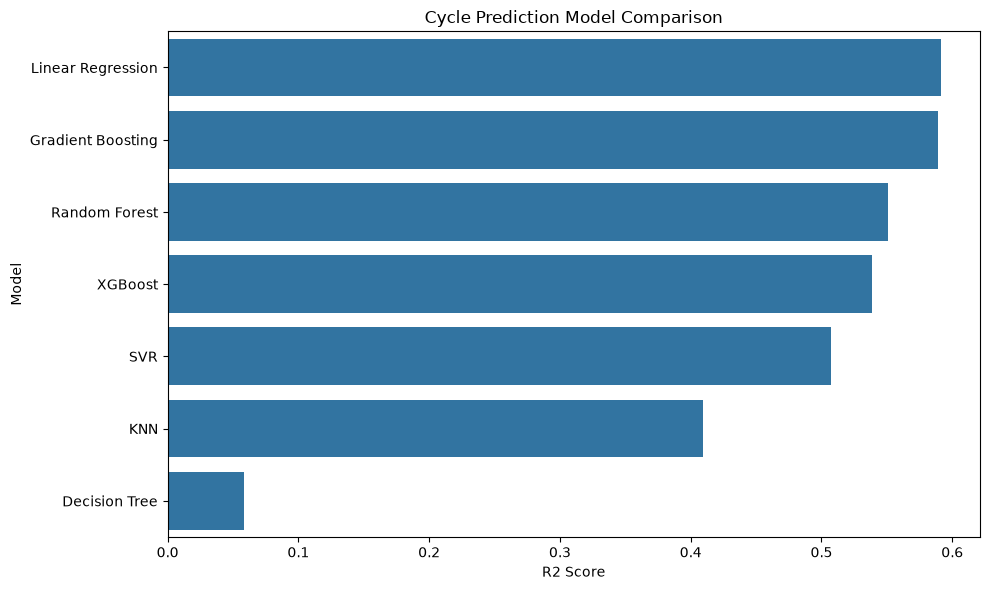

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cycle_results,
    x="R2 Score",
    y="Model"
)

plt.title("Cycle Prediction Model Comparison")

plt.tight_layout()

plt.show()

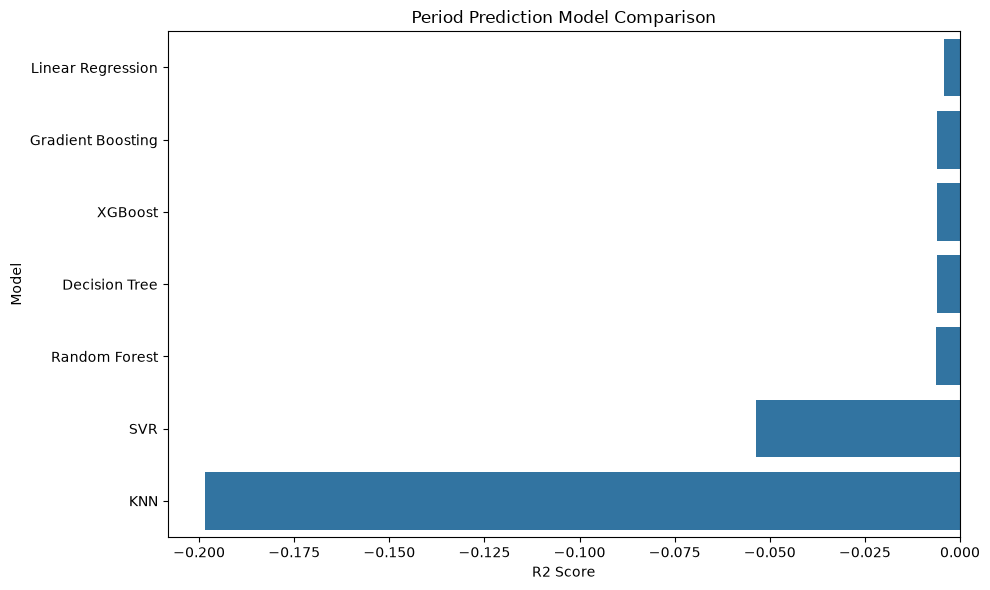

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=period_results,
    x="R2 Score",
    y="Model"
)

plt.title("Period Prediction Model Comparison")

plt.tight_layout()

plt.show()